In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')
print("Shape:", df.shape)
print(df.head())


Shape: (50000, 25)
    Age  Gender Country        City  Membership_Years  Login_Frequency  \
0  43.0    Male  France   Marseille               2.9             14.0   
1  36.0    Male      UK  Manchester               1.6             15.0   
2  45.0  Female  Canada   Vancouver               2.9             10.0   
3  56.0  Female     USA    New York               2.6             10.0   
4  35.0    Male   India       Delhi               3.1             29.0   

   Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
0                  27.4                6.0                   50.6   
1                  42.7               10.3                   37.7   
2                  24.8                1.6                   70.9   
3                  38.4               14.8                   41.7   
4                  51.4                NaN                   19.1   

   Wishlist_Items  ...  Email_Open_Rate  Customer_Service_Calls  \
0             3.0  ...             17.9               

In [3]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [4]:
print("Missing values:\n", df.isnull().sum())

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\nAfter fix:\n", df.isnull().sum())

Missing values:
 Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

After fix:
 Age    

In [5]:
df['Gender'] = df['Gender'].str.strip().str.capitalize()
df['Country'] = df['Country'].str.strip().str.title()
df['City'] = df['City'].str.strip().str.title()

print(df['Gender'].unique())
print(df['Country'].unique())

['Male' 'Female' 'Other']
['France' 'Uk' 'Canada' 'Usa' 'India' 'Japan' 'Germany' 'Australia']


In [6]:
df['Age'] = df['Age'].astype(int)
df['Total_Purchases'] = df['Total_Purchases'].astype(int)
df['Churned'] = df['Churned'].astype(int)
print(df.dtypes)

Age                                int64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                    int64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

In [8]:
df.to_csv('churn_cleaned.csv', index=False)
print("✅ Clean data saved!")

✅ Clean data saved!


---
## Machine Learning Models for Churn Prediction

Using the cleaned data to train and evaluate 3 ML models:
- **Logistic Regression**
- **Random Forest**
- **Gradient Boosting**

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Reload clean data
df_ml = pd.read_csv('churn_cleaned.csv')

# --- Encode categoricals ---
le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# --- Features & target (no train/test split — CV handles it) ---
target_col = 'Churned'
X = df_ml.drop(columns=[target_col])
y = df_ml[target_col]

# --- 5-Fold Stratified CV ---
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1']

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Churn distribution:\n{y.value_counts()}')
print(f'\nUsing {N_SPLITS}-Fold Stratified Cross-Validation (no fixed train/test split)')


Categorical columns to encode: ['Gender', 'Country', 'City', 'Signup_Quarter']
Dataset: 50000 samples, 24 features
Churn distribution:
Churned
0    35550
1    14450
Name: count, dtype: int64

Using 5-Fold Stratified Cross-Validation (no fixed train/test split)


### Model 1 — Logistic Regression


In [10]:
# Pipeline ensures scaling is fitted only on training folds (no data leakage)
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=500, random_state=42))
])

lr_scores = cross_validate(lr_pipe, X, y, cv=skf, scoring=scoring,
                           return_train_score=False, n_jobs=-1)

print('=== Logistic Regression — 5-Fold CV ===')
print(f'Accuracy : {lr_scores["test_accuracy"].mean():.4f}  ± {lr_scores["test_accuracy"].std():.4f}')
print(f'ROC-AUC  : {lr_scores["test_roc_auc"].mean():.4f}  ± {lr_scores["test_roc_auc"].std():.4f}')
print(f'F1-Score : {lr_scores["test_f1"].mean():.4f}  ± {lr_scores["test_f1"].std():.4f}')


=== Logistic Regression — 5-Fold CV ===
Accuracy : 0.7785  ± 0.0028
ROC-AUC  : 0.7886  ± 0.0042
F1-Score : 0.5224  ± 0.0073


### Model 2 — Random Forest


In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_scores = cross_validate(rf, X, y, cv=skf, scoring=scoring,
                           return_train_score=False, n_jobs=-1)

print('=== Random Forest — 5-Fold CV ===')
print(f'Accuracy : {rf_scores["test_accuracy"].mean():.4f}  ± {rf_scores["test_accuracy"].std():.4f}')
print(f'ROC-AUC  : {rf_scores["test_roc_auc"].mean():.4f}  ± {rf_scores["test_roc_auc"].std():.4f}')
print(f'F1-Score : {rf_scores["test_f1"].mean():.4f}  ± {rf_scores["test_f1"].std():.4f}')


=== Random Forest — 5-Fold CV ===
Accuracy : 0.9158  ± 0.0023
ROC-AUC  : 0.9231  ± 0.0042
F1-Score : 0.8421  ± 0.0053


### Model 3 — Gradient Boosting


In [12]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb_scores = cross_validate(gb, X, y, cv=skf, scoring=scoring,
                           return_train_score=False, n_jobs=-1)

print('=== Gradient Boosting — 5-Fold CV ===')
print(f'Accuracy : {gb_scores["test_accuracy"].mean():.4f}  ± {gb_scores["test_accuracy"].std():.4f}')
print(f'ROC-AUC  : {gb_scores["test_roc_auc"].mean():.4f}  ± {gb_scores["test_roc_auc"].std():.4f}')
print(f'F1-Score : {gb_scores["test_f1"].mean():.4f}  ± {gb_scores["test_f1"].std():.4f}')


=== Gradient Boosting — 5-Fold CV ===
Accuracy : 0.9175  ± 0.0040
ROC-AUC  : 0.9256  ± 0.0040
F1-Score : 0.8439  ± 0.0088


---
## 📊 EDA Visualizations


In [ ]:
# ── 1. Bar: Top 8 Countries by Churn ─────────────────────────────────────
plt.figure(figsize=(12, 6))
churn_country = df[df['Churned'] == 1]['Country'].value_counts().head(8)
plt.bar(churn_country.index, churn_country.values, color='crimson')
plt.title('Top 8 Countries by Customer Churn')
plt.xlabel('Country'); plt.ylabel('Churned Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150)
plt.show()

# ── 2. Pie: Churn Distribution ────────────────────────────────────────────
plt.figure(figsize=(7, 7))
sizes = df['Churned'].value_counts()
plt.pie(sizes, labels=['Stayed', 'Churned'], colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%')
plt.title('Customer Churn Distribution')
plt.savefig('pie_chart.png', dpi=150)
plt.show()

# ── 3. Line: Avg Lifetime Value by Age ───────────────────────────────────
plt.figure(figsize=(12, 5))
age_ltv = df.groupby('Age')['Lifetime_Value'].mean()
plt.plot(age_ltv.index, age_ltv.values, color='steelblue', linewidth=2)
plt.title('Average Lifetime Value by Age')
plt.xlabel('Age'); plt.ylabel('Lifetime Value ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('line_chart.png', dpi=150)
plt.show()

# ── 4. Histogram: Session Duration ───────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.hist(df['Session_Duration_Avg'], bins=30, color='orange', edgecolor='black')
plt.title('Distribution of Session Duration')
plt.xlabel('Session Duration (minutes)'); plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('histogram.png', dpi=150)
plt.show()


---
## 🔀 MapReduce — Churn Count by Country

Simulating a MapReduce pipeline (Map → Shuffle → Reduce) to aggregate churned customers per country.


In [14]:
# ==========================================
# MapReduce Simulation - Churn Count by Country
# ==========================================

import pandas as pd
from collections import defaultdict

df = pd.read_csv('churn_cleaned.csv')

# ========== MAP PHASE ==========
def mapper(dataframe):
    mapped = []
    for _, row in dataframe.iterrows():
        if row['Churned'] == 1:
            mapped.append((row['Country'], 1))
    return mapped

# ========== SHUFFLE PHASE ==========
def shuffle(mapped_data):
    shuffled = defaultdict(list)
    for country, value in mapped_data:
        shuffled[country].append(value)
    return shuffled

# ========== REDUCE PHASE ==========
def reducer(shuffled_data):
    result = {}
    for country, values in shuffled_data.items():
        result[country] = sum(values)
    return result

# ========== RUN MAPREDUCE ==========
print("🔵 MAP Phase running...")
mapped = mapper(df)
print(f"   Mapped {len(mapped)} churned customers")

print("\n🟡 SHUFFLE Phase running...")
shuffled = shuffle(mapped)
print(f"   Grouped into {len(shuffled)} countries")

print("\n🔴 REDUCE Phase running...")
result = reducer(shuffled)

# ========== SHOW RESULTS ==========
result_df = pd.DataFrame(list(result.items()),
                         columns=['Country', 'Churned_Count'])
result_df = result_df.sort_values('Churned_Count', ascending=False)

print("\n✅ MapReduce Result:")
print(result_df.to_string(index=False))

🔵 MAP Phase running...
   Mapped 14450 churned customers

🟡 SHUFFLE Phase running...
   Grouped into 8 countries

🔴 REDUCE Phase running...

✅ MapReduce Result:
  Country  Churned_Count
      Usa           5056
       Uk           2169
   Canada           1768
  Germany           1420
Australia           1214
   France           1095
    India           1019
    Japan            709


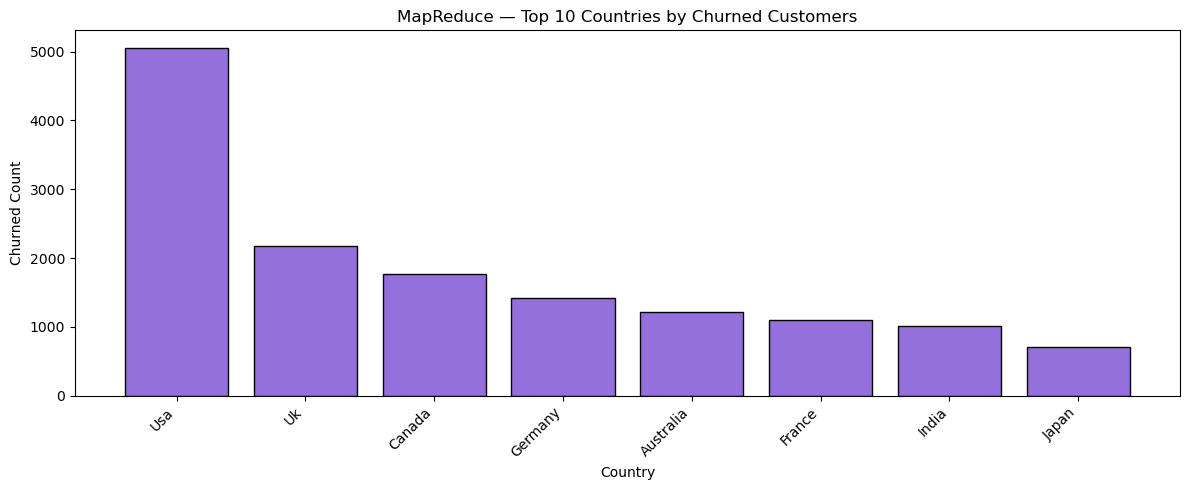

In [15]:
# ── 5. MapReduce result bar chart ────────────────────────────────────────
mr_df = result_df.head(10)   # result_df built in the MapReduce cell above
plt.figure(figsize=(12, 5))
plt.bar(mr_df['Country'], mr_df['Churned_Count'], color='mediumpurple', edgecolor='black')
plt.title('MapReduce — Top 10 Countries by Churned Customers')
plt.xlabel('Country'); plt.ylabel('Churned Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('mapreduce_chart.png', dpi=150)
plt.show()


---
## 📈 Model Evaluation Visuals

All model performance charts: confusion matrices, ROC curves, CV score distributions, and feature importance.


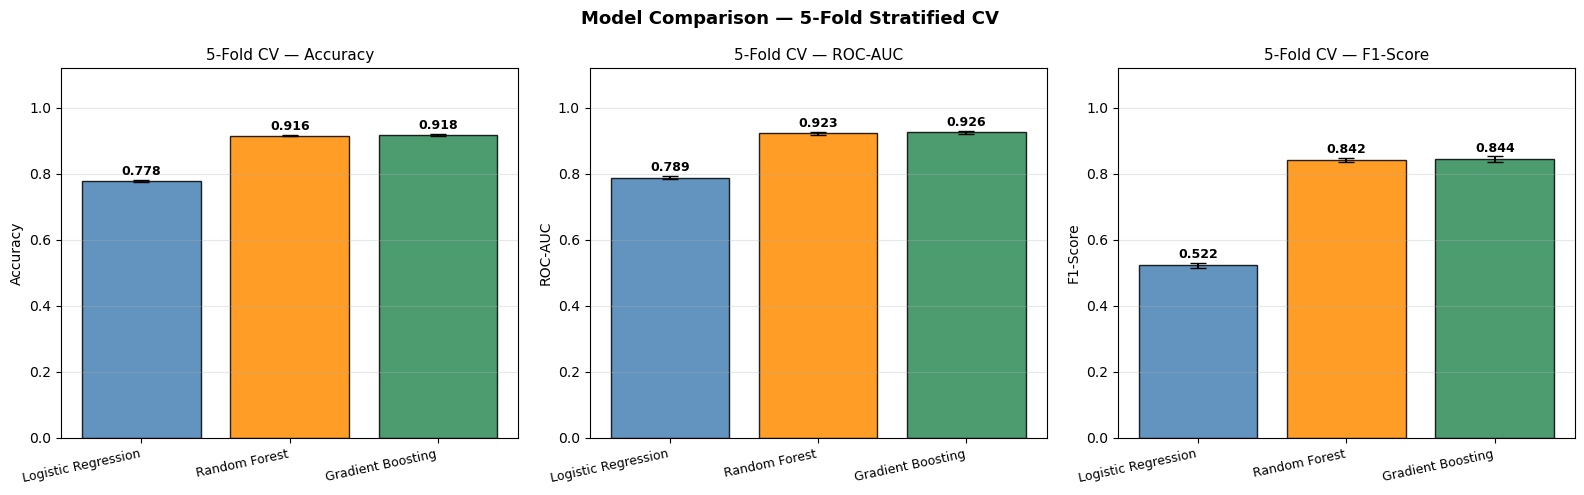

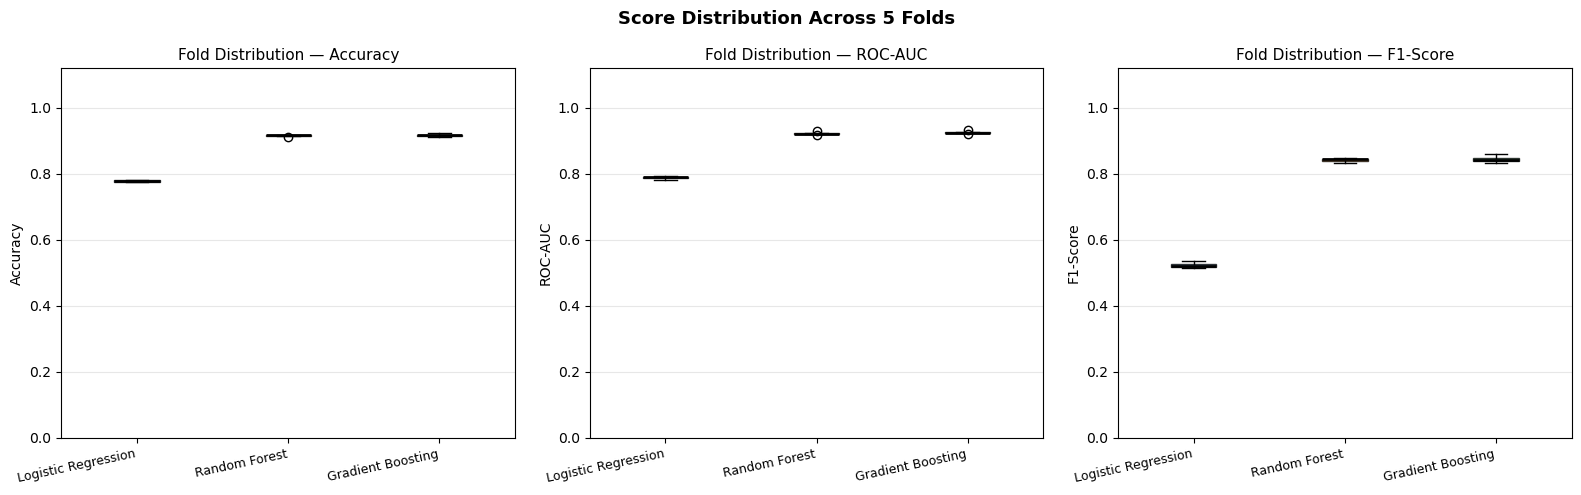

In [17]:
# ── 6 & 7. CV bar chart + box plot ───────────────────────────────────────
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
all_scores  = [lr_scores, rf_scores, gb_scores]
colors_cv   = ['steelblue', 'darkorange', 'seagreen']
metric_keys = ['test_accuracy', 'test_roc_auc', 'test_f1']
metric_lbls = ['Accuracy', 'ROC-AUC', 'F1-Score']

# 6 — Bar with error bars
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, mkey, mlbl in zip(axes, metric_keys, metric_lbls):
    means = [s[mkey].mean() for s in all_scores]
    stds  = [s[mkey].std()  for s in all_scores]
    x_pos = np.arange(len(model_names))
    bars  = ax.bar(x_pos, means, yerr=stds, capsize=6,
                   color=colors_cv, edgecolor='black', alpha=0.85)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=12, ha='right', fontsize=9)
    ax.set_title(f'{N_SPLITS}-Fold CV — {mlbl}', fontsize=11)
    ax.set_ylabel(mlbl); ax.set_ylim(0, 1.12); ax.grid(axis='y', alpha=0.3)
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + 0.015,
                f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.suptitle(f'Model Comparison — {N_SPLITS}-Fold Stratified CV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# 7 — Box plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, mkey, mlbl in zip(axes, metric_keys, metric_lbls):
    data = [s[mkey] for s in all_scores]
    bp   = ax.boxplot(data, patch_artist=True, notch=False,
                      medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors_cv):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticklabels(model_names, rotation=12, ha='right', fontsize=9)
    ax.set_title(f'Fold Distribution — {mlbl}', fontsize=11)
    ax.set_ylabel(mlbl); ax.set_ylim(0, 1.12); ax.grid(axis='y', alpha=0.3)
plt.suptitle(f'Score Distribution Across {N_SPLITS} Folds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kfold_boxplot.png', dpi=150)
plt.show()


In [ ]:
# ── 8. Confusion Matrices (last fold predictions via cross_val_predict) ───
from sklearn.model_selection import cross_val_predict

preds = {
    'Logistic Regression': cross_val_predict(lr_pipe, X, y, cv=skf, n_jobs=-1),
    'Random Forest'      : cross_val_predict(rf,      X, y, cv=skf, n_jobs=-1),
    'Gradient Boosting'  : cross_val_predict(gb,      X, y, cv=skf, n_jobs=-1),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Stay', 'Churn'],
                yticklabels=['Stay', 'Churn'])
    ax.set_title(f'{name}\nAcc={accuracy_score(y, y_pred):.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Cross-Validated Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# Print full classification report for each model
for name, y_pred in preds.items():
    print(f'\n=== {name} ===')
    print(classification_report(y, y_pred, target_names=['Stay', 'Churn']))


In [ ]:
# ── 9. ROC Curves ────────────────────────────────────────────────────────
proba_models = [
    ('Logistic Regression', lr_pipe),
    ('Random Forest',       rf),
    ('Gradient Boosting',   gb),
]

fig, ax = plt.subplots(figsize=(8, 6))
for name, model in proba_models:
    y_prob = cross_val_predict(model, X, y, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Cross-Validated Probabilities')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()


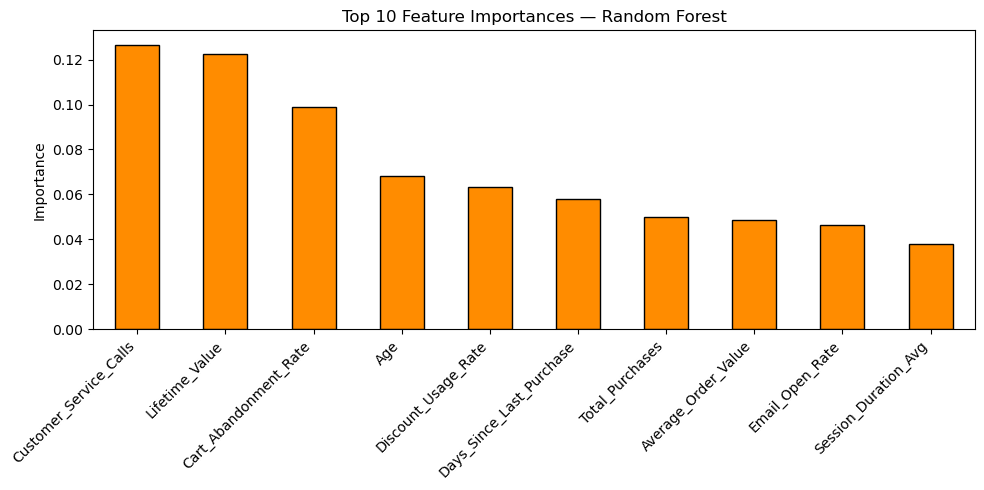

In [19]:
# ── 10. Feature Importance — Random Forest (refit on full data) ───────────
rf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X, y)
feat_imp = pd.Series(rf_full.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.head(10).plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Top 10 Feature Importances — Random Forest')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


---
| Section | Description |
|---|---|
| **Data Cleaning** | Duplicates, missing values, type fixes |
| **ML Models** | Logistic Regression, Random Forest, Gradient Boosting via 5-Fold CV |
| **EDA Visuals** | Bar, Pie, Line, Histogram |
| **MapReduce** | Churn aggregation by country (Map → Shuffle → Reduce) |
| **Model Visuals** | CV scores, Confusion Matrices, ROC Curves, Feature Importance |
